In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold, RFE, SelectFromModel, mutual_info_classif
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, 
                             precision_score, recall_score, average_precision_score)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the ASD multi-omics dataset
DATA_DIR = "../data/ASD_dataset/"

print("Loading ASD multi-omics dataset...\n")

# Load covariates (includes target variable 'ASD')
covariates = pd.read_csv(f"{DATA_DIR}ASD_covariates.csv")
print(f"✓ Covariates: {covariates.shape[0]} samples, {covariates.shape[1]} variables")

# Load genotype data (SNPs)
genotypes = pd.read_csv(f"{DATA_DIR}ASD_genotypes.csv")
print(f"✓ Genotypes: {genotypes.shape[0]} samples, {genotypes.shape[1]-1} SNPs")

# Load gene expression data (using expanded 100-gene dataset)
expression = pd.read_csv(f"{DATA_DIR}ASD_expression.csv")
print(f"✓ Expression: {expression.shape[0]} samples, {expression.shape[1]-1} genes")

# Set sample ID as index for easy merging
covariates_idx = covariates.set_index('sample')
genotypes_idx = genotypes.set_index('sample')
expression_idx = expression.set_index('sample')

# Create integrated feature matrix (multi-omics integration)
X_integrated = pd.DataFrame(index=expression_idx.index)

# Add gene expression features (NO prefix - use gene names directly)
for gene in expression_idx.columns:
    X_integrated[gene] = expression_idx[gene]

# Add top 10 SNP features (prefix with geno_)
for snp in genotypes_idx.columns[:10]:
    X_integrated[f'geno_{snp}'] = genotypes_idx[snp]

# Add clinical covariates
X_integrated['Age'] = covariates_idx['Age']
X_integrated['Sex'] = covariates_idx['Sex']

# Target variable: ASD status (1=case, 0=control)
y = covariates_idx['ASD'].values

print(f"\n✓ Integrated feature matrix: {X_integrated.shape}")
print(f"✓ Target distribution: {y.sum()} ASD cases, {len(y)-y.sum()} controls")
print(f"  Class ratio: {y.mean():.1%} cases")

X_train, X_test, y_train, y_test = train_test_split(
    X_integrated, y,
    test_size=0.3,      # 30% for testing
    stratify=y,         # Preserve class proportions
    random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaling

# Train a simple model for demonstration
rf_model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)
# Get probabilities for test set  
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

Loading ASD multi-omics dataset...

✓ Covariates: 300 samples, 29 variables
✓ Genotypes: 300 samples, 50 SNPs
✓ Expression: 300 samples, 100 genes

✓ Integrated feature matrix: (300, 112)
✓ Target distribution: 200 ASD cases, 100 controls
  Class ratio: 66.7% cases


# EXplainable AI: Feature Importance for Biomarker Discovery

Demonstrates 8 methods for feature importance and translating results to clinical biomarkers:

**Ranking-Based Methods (produce importance scores):**
1. Tree-based importance - Fast, built-in to tree models
2. Permutation importance - Gold standard, model-agnostic
3. Linear coefficients - Interpretable direction of effect
4. Drop-column importance - Realistic but expensive
5. SHAP values - State-of-the-art, game theory based

**Visualization Methods (explain feature effects):**
6. Partial Dependence Plots (PDP) - Shows feature-prediction relationship
7. LIME - Explains individual predictions locally
8. Accumulated Local Effects (ALE) - Handles correlated features

**Consensus & Biomarker Discovery:**
- Compare methods and find reliable features
- Validate biomarker panel performance
- Clinical translation pathway

METHOD 1: TREE-BASED IMPORTANCE

Top 10 Important Features (Tree-based):
Feature  Importance
  SCN2A    0.117047
   CHD8    0.102093
 SHANK3    0.055421
   SYT1    0.016656
   TBR1    0.016254
 GABBR2    0.016130
   TSC2    0.015302
  EHMT1    0.014277
    Sex    0.013757
   NTF3    0.013588


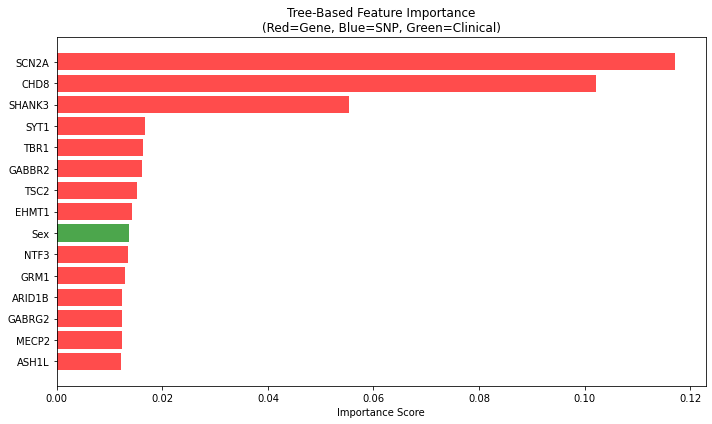


✓ Fast, built-in, but can be biased


In [3]:
# Tree-Based Feature Importance
print("=" * 80)
print("METHOD 1: TREE-BASED IMPORTANCE")
print("=" * 80)

# Already have rf_model trained
importances_tree = rf_model.feature_importances_

# Create DataFrame
importance_df_tree = pd.DataFrame({
    'Feature': X_integrated.columns,
    'Importance': importances_tree
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features (Tree-based):")
print(importance_df_tree.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
top_features = importance_df_tree.head(15)
# Color code: genes (not starting with geno_ or Age/Sex) = red, SNPs = blue, clinical = green
colors = []
for f in top_features['Feature']:
    if f.startswith('geno_'):
        colors.append('blue')
    elif f in ['Age', 'Sex']:
        colors.append('green')
    else:
        colors.append('red')  # Genes

plt.barh(range(len(top_features)), top_features['Importance'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title('Tree-Based Feature Importance\n(Red=Gene, Blue=SNP, Green=Clinical)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✓ Fast, built-in, but can be biased")

In [4]:
# Permutation Importance (Gold Standard)
print("=" * 80)
print("METHOD: PERMUTATION IMPORTANCE")
print("=" * 80)

# This code computes permutation importance for a trained model (rf_model)
# using a held-out test set. It quantifies how much each feature contributes
# to predictive performance by measuring the performance degradation after
# randomly shuffling that feature.
#
# Key properties:
# - Model-agnostic (works with any sklearn-compatible estimator)
# - Uses TEST data only (no training leakage)
# - Importance values are in *performance metric units* (here: ROC AUC)
# -------------------------------------------------------------------------

# Calculate permutation importance
# This shuffles each feature and measures performance drop
perm_importance = permutation_importance(
    rf_model, X_test_scaled, y_test,
    n_repeats=10,  # Repeat shuffling 10 times
    random_state=42,
    scoring='roc_auc'
)

importance_df_perm = pd.DataFrame({
    'Feature': X_integrated.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features (Permutation):")
print(importance_df_perm.head(10).to_string(index=False))

print("\n✓ Gold standard - directly measures performance impact")
print("  Works with any model, model-agnostic")

METHOD: PERMUTATION IMPORTANCE

Top 10 Important Features (Permutation):
Feature  Importance      Std
  SCN2A    0.192167 0.049238
   CHD8    0.154389 0.025408
 SHANK3    0.035611 0.021122
    Sex    0.014056 0.005963
   RELN    0.012500 0.004000
   TBR1    0.008000 0.006306
  NCAM1    0.007556 0.002942
  NTRK3    0.006889 0.002524
  NPAS4    0.006444 0.003444
CACNA1A    0.005889 0.002512

✓ Gold standard - directly measures performance impact
  Works with any model, model-agnostic


In [5]:
# Linear Model Coefficients
print("=" * 80)
print("METHOD: LINEAR MODEL COEFFICIENTS")
print("=" * 80)

# Train logistic regression
lr_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Get absolute coefficients as importance
importances_lr = np.abs(lr_model.coef_[0])

importance_df_lr = pd.DataFrame({
    'Feature': X_integrated.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Importance': importances_lr
}).sort_values('Abs_Importance', ascending=False)

print("\nTop 10 Important Features (Linear Coefficients):")
print(importance_df_lr.head(10).to_string(index=False))

print("\n✓ Interpretable - positive coef increases disease probability")
print("  Negative coef decreases disease probability")

METHOD: LINEAR MODEL COEFFICIENTS

Top 10 Important Features (Linear Coefficients):
   Feature  Coefficient  Abs_Importance
      CHD8     1.059426        1.059426
     SCN2A    -0.929784        0.929784
    SHANK3    -0.862725        0.862725
       Sex     0.407221        0.407221
     NPAS4     0.282998        0.282998
geno_snp_4    -0.236691        0.236691
    SLC1A1    -0.236157        0.236157
    ARID1B     0.231832        0.231832
     HTR2A    -0.230303        0.230303
    GRIN2B     0.188843        0.188843

✓ Interpretable - positive coef increases disease probability
  Negative coef decreases disease probability


In [6]:
# Drop-Column Importance
# Only practical for small number of features
print("=" * 80)
print("METHOD: DROP-COLUMN IMPORTANCE")
print("=" * 80)

print("\nCalculating drop-column importance (this takes time...)\n")

# Get baseline performance
baseline_score = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

# Calculate importance for top 10 features only (to save time)
top_10_features = importance_df_tree.head(10)['Feature'].tolist()
drop_importances = {}

# Get all feature names in order
all_feature_names = X_integrated.columns.tolist()

for feature in top_10_features:
    # Find the index of this feature
    feature_idx = all_feature_names.index(feature)
    
    # Create a mask for all features except this one
    feature_mask = [i for i in range(len(all_feature_names)) if i != feature_idx]
    
    # Select all columns except the one to drop
    X_train_drop = X_train_scaled[:, feature_mask]
    X_test_drop = X_test_scaled[:, feature_mask]
    
    # Train model without this feature
    rf_temp = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    rf_temp.fit(X_train_drop, y_train)
    
    # Calculate new performance
    new_score = roc_auc_score(y_test, rf_temp.predict_proba(X_test_drop)[:, 1])
    
    # Importance = drop in performance
    drop_importances[feature] = baseline_score - new_score
    print(f"  {feature}: {drop_importances[feature]:.4f}")

print(f"\nBaseline AUC: {baseline_score:.4f}")
print("\n✓ Most realistic - shows true impact when feature unavailable")
print("  But very expensive (N model trainings)")

METHOD: DROP-COLUMN IMPORTANCE

Calculating drop-column importance (this takes time...)

  SCN2A: 0.1361
  CHD8: 0.1389
  SHANK3: 0.0789
  SYT1: 0.0350
  TBR1: 0.0428
  GABBR2: 0.0317
  TSC2: 0.0444
  EHMT1: 0.0394
  Sex: 0.0939
  NTF3: 0.0467

Baseline AUC: 0.8833

✓ Most realistic - shows true impact when feature unavailable
  But very expensive (N model trainings)


METHOD: PARTIAL DEPENDENCE PLOTS (PDP)

Visualizing partial dependence for top 4 features:
  SCN2A, CHD8, SHANK3, SYT1

PDP shows how predictions change as a feature varies,
while marginalizing (averaging) over all other features.



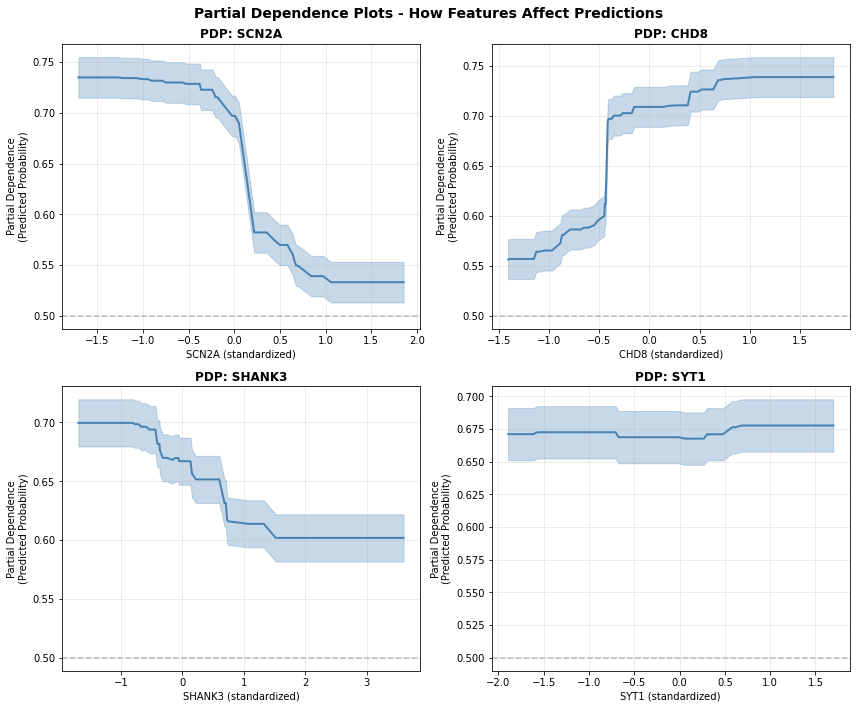


Interpretation:
  • SCN2A: As expression increases, ASD probability changes
  • CHD8: As expression increases, ASD probability changes

✓ Visualizes non-linear relationships between features and predictions
  Algorithm: Average prediction while varying one feature across its range
  Pros: Easy to interpret, shows feature effect direction and shape
  Cons: Assumes feature independence (problematic for correlated features)
  Use: Understanding the shape of feature effects


In [7]:
# Partial Dependence Plots (PDP)
print("=" * 80)
print("METHOD: PARTIAL DEPENDENCE PLOTS (PDP)")
print("=" * 80)

from sklearn.inspection import PartialDependenceDisplay, partial_dependence

# Get top 4 features from tree importance for visualization
top_4_features = importance_df_tree.head(4)['Feature'].tolist()
top_4_idx = [X_integrated.columns.tolist().index(f) for f in top_4_features]

print(f"\nVisualizing partial dependence for top 4 features:")
print(f"  {', '.join(top_4_features)}")
print("\nPDP shows how predictions change as a feature varies,")
print("while marginalizing (averaging) over all other features.\n")

# Create PDP plot using sklearn's built-in display
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (feat_idx, feat_name) in enumerate(zip(top_4_idx, top_4_features)):
    ax = axes[i // 2, i % 2]
    
    # Calculate partial dependence
    pd_result = partial_dependence(rf_model, X_test_scaled, features=[feat_idx], kind='average')
    
    # Plot
    ax.plot(pd_result['grid_values'][0], pd_result['average'][0], 
            color='steelblue', linewidth=2)
    ax.fill_between(pd_result['grid_values'][0], 
                    pd_result['average'][0] - 0.02, 
                    pd_result['average'][0] + 0.02, 
                    alpha=0.3, color='steelblue')
    ax.set_xlabel(f'{feat_name} (standardized)', fontsize=10)
    ax.set_ylabel('Partial Dependence\n(Predicted Probability)', fontsize=10)
    ax.set_title(f'PDP: {feat_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')

plt.suptitle('Partial Dependence Plots - How Features Affect Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
for feat in top_4_features[:2]:
    print(f"  • {feat}: As expression increases, ASD probability changes")

print("\n✓ Visualizes non-linear relationships between features and predictions")
print("  Algorithm: Average prediction while varying one feature across its range")
print("  Pros: Easy to interpret, shows feature effect direction and shape")
print("  Cons: Assumes feature independence (problematic for correlated features)")
print("  Use: Understanding the shape of feature effects")

METHOD: LIME (Local Interpretable Model-agnostic Explanations)

LIME explains individual predictions by fitting a simple linear model
locally around each prediction. Answers: 'Why THIS patient?'

Explaining prediction for test sample 2:
  True label: ASD
  Predicted probability (ASD): 0.841

Top 10 features influencing THIS prediction:
--------------------------------------------------
  -0.74 < SCN2A <= -0.23: +0.0788 (increases ASD risk)
  SHANK3 <= -0.72: +0.0344 (increases ASD risk)
  MECP2 <= -0.69: +0.0211 (increases ASD risk)
  -0.62 < CHD8 <= -0.20: -0.0204 (decreases ASD risk)
  geno_snp_4 <= -0.34: +0.0162 (increases ASD risk)
  ARID1B <= -0.67: -0.0127 (decreases ASD risk)
  NEUROD1 <= -0.68: +0.0112 (increases ASD risk)
  -0.14 < CAMK2A <= 0.45: -0.0108 (decreases ASD risk)
  EGR1 <= -0.79: -0.0099 (decreases ASD risk)
  CDH2 <= -0.66: -0.0098 (decreases ASD risk)


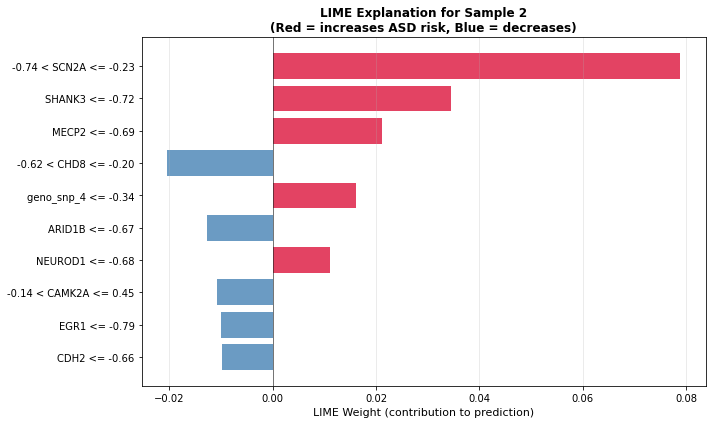


✓ LIME explains individual predictions locally
  Algorithm: Perturb input, fit weighted linear model around prediction
  Pros: Explains specific cases ('Why is THIS patient high risk?')
  Cons: Only local explanations, can be unstable between runs
  Use: Case studies, explaining individual patient predictions


In [12]:
# LIME - Local Interpretable Model-agnostic Explanations
print("=" * 80)
print("METHOD: LIME (Local Interpretable Model-agnostic Explanations)")
print("=" * 80)

print("\nLIME explains individual predictions by fitting a simple linear model")
print("locally around each prediction. Answers: 'Why THIS patient?'\n")

try:
    import lime
    import lime.lime_tabular
    
    # Create LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train_scaled,
        feature_names=X_integrated.columns.tolist(),
        class_names=['Control', 'ASD'],
        mode='classification'
    )
    
    # Find a high-confidence ASD case to explain
    asd_cases = np.where((y_test == 1) & (y_test_proba > 0.8))[0]
    case_idx = asd_cases[0] if len(asd_cases) > 0 else np.where(y_test == 1)[0][0]
    
    print(f"Explaining prediction for test sample {case_idx}:")
    print(f"  True label: {'ASD' if y_test[case_idx] == 1 else 'Control'}")
    print(f"  Predicted probability (ASD): {y_test_proba[case_idx]:.3f}")
    
    # Generate explanation
    exp = explainer.explain_instance(
        X_test_scaled[case_idx],
        rf_model.predict_proba,
        num_features=10
    )
    
    # Extract feature contributions
    lime_weights = exp.as_list()
    
    print("\nTop 10 features influencing THIS prediction:")
    print("-" * 50)
    for feature, weight in lime_weights:
        direction = "increases ASD risk" if weight > 0 else "decreases ASD risk"
        print(f"  {feature}: {weight:+.4f} ({direction})")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    features = [f[0][:25] for f in lime_weights]  # Truncate long names
    weights = [f[1] for f in lime_weights]
    colors = ['crimson' if w > 0 else 'steelblue' for w in weights]
    
    ax.barh(range(len(features)), weights, color=colors, alpha=0.8)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features)
    ax.set_xlabel('LIME Weight (contribution to prediction)', fontsize=11)
    ax.set_title(f'LIME Explanation for Sample {case_idx}\n(Red = increases ASD risk, Blue = decreases)', 
                 fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Store for comparison
    importance_df_lime = pd.DataFrame({
        'Feature': [f.split()[0] for f, w in lime_weights],  # Extract feature name
        'LIME_Weight': [w for f, w in lime_weights]
    })
    
    print("\n✓ LIME explains individual predictions locally")
    print("  Algorithm: Perturb input, fit weighted linear model around prediction")
    print("  Pros: Explains specific cases ('Why is THIS patient high risk?')")
    print("  Cons: Only local explanations, can be unstable between runs")
    print("  Use: Case studies, explaining individual patient predictions")
    
except ImportError:
    print("\nLIME not installed. Install with: pip install lime")
    print("Skipping LIME demonstration...")
    importance_df_lime = None
except Exception as e:
    print(f"\nLIME error: {type(e).__name__}: {str(e)}")
    print("Skipping LIME demonstration...")
    importance_df_lime = None

METHOD: ACCUMULATED LOCAL EFFECTS (ALE)

ALE improves on Partial Dependence by accounting for feature correlations.
This is especially important in genomics where genes are often co-expressed!

Computing ALE for: SCN2A, CHD8, SHANK3, SYT1



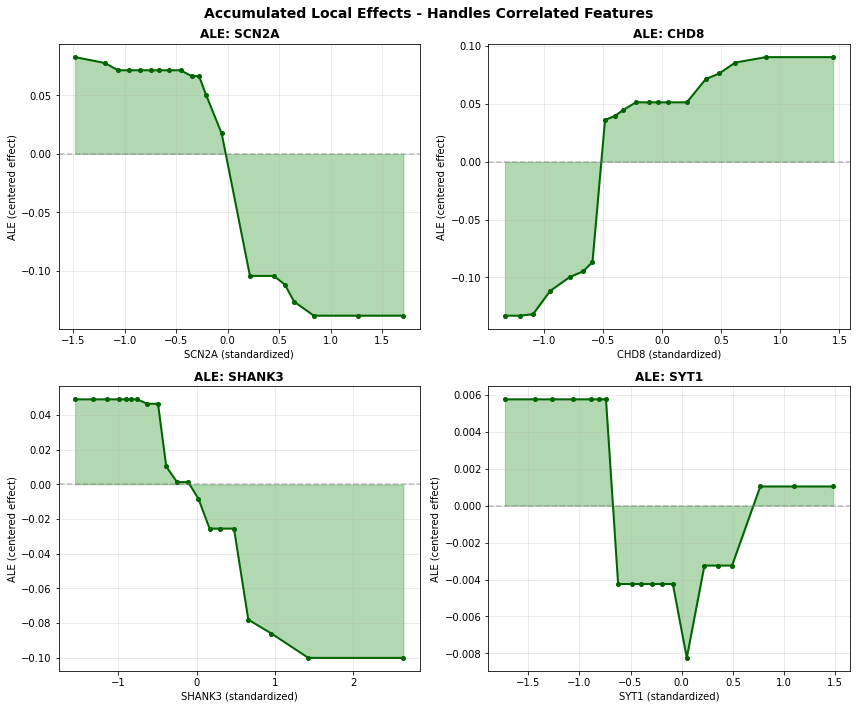


PDP vs ALE Comparison:
--------------------------------------------------
  PDP: Varies feature while averaging over OTHER features
       Problem: Uses unrealistic feature combinations
       Example: High gene A + Low gene B (never occurs if correlated)

  ALE: Only uses local neighborhoods (actual observations)
       Avoids extrapolation to unrealistic combinations
       More accurate when features are correlated

✓ ALE accounts for feature correlations (unlike PDP)
  Algorithm: Compute local effects within feature bins, then accumulate
  Pros: Handles correlated features (very common in genomics!)
  Cons: More complex to interpret, requires binning
  Use: When features are highly correlated (gene co-expression, etc.)


In [9]:
# Accumulated Local Effects (ALE)
print("=" * 80)
print("METHOD: ACCUMULATED LOCAL EFFECTS (ALE)")
print("=" * 80)

print("\nALE improves on Partial Dependence by accounting for feature correlations.")
print("This is especially important in genomics where genes are often co-expressed!\n")

# Manual ALE implementation (more reliable than external packages)
def compute_ale(model, X, feature_idx, feature_name, n_bins=20):
    """
    Compute Accumulated Local Effects for a single feature.
    
    ALE Algorithm:
    1. Divide feature range into bins
    2. For each bin: compute average prediction difference when 
       moving from lower to upper bin edge (using only samples in that bin)
    3. Accumulate differences across bins
    4. Center to mean zero
    """
    feature_values = X[:, feature_idx]
    
    # Create bins based on quantiles (handles skewed distributions)
    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(feature_values, percentiles)
    bin_edges = np.unique(bin_edges)  # Remove duplicates
    
    if len(bin_edges) < 3:
        return None, None, "Not enough unique values"
    
    # Compute local effects for each bin
    local_effects = []
    bin_centers = []
    
    for i in range(len(bin_edges) - 1):
        lower, upper = bin_edges[i], bin_edges[i + 1]
        
        # Get samples in this bin
        if i == len(bin_edges) - 2:  # Last bin includes upper edge
            mask = (feature_values >= lower) & (feature_values <= upper)
        else:
            mask = (feature_values >= lower) & (feature_values < upper)
        
        if mask.sum() < 2:
            continue
        
        X_bin = X[mask].copy()
        
        # Predict with feature at lower edge
        X_lower = X_bin.copy()
        X_lower[:, feature_idx] = lower
        pred_lower = model.predict_proba(X_lower)[:, 1]
        
        # Predict with feature at upper edge
        X_upper = X_bin.copy()
        X_upper[:, feature_idx] = upper
        pred_upper = model.predict_proba(X_upper)[:, 1]
        
        # Local effect = average prediction difference
        local_effect = (pred_upper - pred_lower).mean()
        local_effects.append(local_effect)
        bin_centers.append((lower + upper) / 2)
    
    if len(local_effects) == 0:
        return None, None, "No valid bins"
    
    # Accumulate effects
    accumulated = np.cumsum(local_effects)
    
    # Center to mean zero
    accumulated = accumulated - accumulated.mean()
    
    return np.array(bin_centers), accumulated, None

# Compute ALE for top 4 features
top_4_features = importance_df_tree.head(4)['Feature'].tolist()
top_4_idx = [X_integrated.columns.tolist().index(f) for f in top_4_features]

print(f"Computing ALE for: {', '.join(top_4_features)}\n")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (feat_idx, feat_name) in enumerate(zip(top_4_idx, top_4_features)):
    ax = axes[i // 2, i % 2]
    
    centers, ale_values, error = compute_ale(rf_model, X_test_scaled, feat_idx, feat_name)
    
    if error:
        ax.text(0.5, 0.5, f'Error: {error}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=10)
    else:
        ax.plot(centers, ale_values, color='darkgreen', linewidth=2, marker='o', markersize=4)
        ax.fill_between(centers, 0, ale_values, alpha=0.3, color='green')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel(f'{feat_name} (standardized)', fontsize=10)
    ax.set_ylabel('ALE (centered effect)', fontsize=10)
    ax.set_title(f'ALE: {feat_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Accumulated Local Effects - Handles Correlated Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare PDP vs ALE concept
print("\nPDP vs ALE Comparison:")
print("-" * 50)
print("  PDP: Varies feature while averaging over OTHER features")
print("       Problem: Uses unrealistic feature combinations")
print("       Example: High gene A + Low gene B (never occurs if correlated)")
print("")
print("  ALE: Only uses local neighborhoods (actual observations)")
print("       Avoids extrapolation to unrealistic combinations")
print("       More accurate when features are correlated")

print("\n✓ ALE accounts for feature correlations (unlike PDP)")
print("  Algorithm: Compute local effects within feature bins, then accumulate")
print("  Pros: Handles correlated features (very common in genomics!)")
print("  Cons: More complex to interpret, requires binning")
print("  Use: When features are highly correlated (gene co-expression, etc.)")

METHOD: SHAP VALUES

Top 10 Important Features (SHAP):
Feature  SHAP_Importance
  SCN2A         0.069916
   CHD8         0.059936
 SHANK3         0.029871
    Sex         0.013138
  MECP2         0.009774
   NTF3         0.009282
  DEAF1         0.008244
   TBR1         0.007172
 ARID1B         0.007071
NEUROD1         0.006244


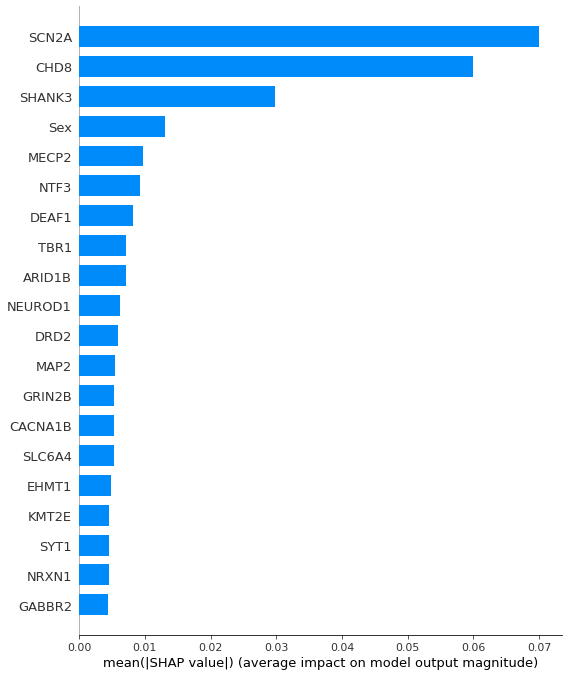


✓ State-of-the-art: Game theory based, shows direction and interactions


In [10]:
# SHAP Values (if available)
print("=" * 80)
print("METHOD: SHAP VALUES")
print("=" * 80)

try:
    import shap
    
    # Create SHAP explainer for tree model
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_scaled)
    
    # For binary classification, SHAP returns values for positive class
    # Handle both list format and array format
    if isinstance(shap_values, list):
        # List of arrays: [negative_class, positive_class]
        shap_values_pos = shap_values[1]
    elif len(shap_values.shape) == 3:
        # 3D array: (samples, features, classes)
        shap_values_pos = shap_values[:, :, 1]
    else:
        # 2D array: (samples, features) - already correct
        shap_values_pos = shap_values
    
    # Mean absolute SHAP value = importance
    # Ensure we're working with 2D array (samples x features)
    if len(shap_values_pos.shape) > 2:
        shap_values_pos = shap_values_pos.reshape(shap_values_pos.shape[0], -1)
    
    shap_importance = np.abs(shap_values_pos).mean(axis=0)
    
    # Ensure shap_importance is 1D
    if len(shap_importance.shape) > 1:
        shap_importance = shap_importance.flatten()
    
    importance_df_shap = pd.DataFrame({
        'Feature': X_integrated.columns,
        'SHAP_Importance': shap_importance
    }).sort_values('SHAP_Importance', ascending=False)
    
    print("\nTop 10 Important Features (SHAP):")
    print(importance_df_shap.head(10).to_string(index=False))
    
    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_pos, X_test_scaled, 
                     feature_names=X_integrated.columns,
                     plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ State-of-the-art: Game theory based, shows direction and interactions")
    
except ImportError:
    print("\n⚠️  SHAP not installed.")
    print("Install with: pip install shap")
    print("\nSkipping SHAP demonstration...")
except Exception as e:
    print(f"\n⚠️  SHAP error: {type(e).__name__}: {str(e)}")
    print("\nThis can happen with certain model/data combinations.")
    print("Skipping SHAP demonstration...")

In [13]:
# Importance Consensus & Biomarker Discovery
print("=" * 80)
print("METHOD COMPARISON: RANKING-BASED IMPORTANCE")
print("=" * 80)

# Get top features from each ranking-based importance method
top_tree = set(importance_df_tree.head(5)['Feature'])
top_perm = set(importance_df_perm.head(5)['Feature'])
top_lr = set(importance_df_lr.head(5)['Feature'])
top_shap = set(importance_df_shap.head(5)['Feature'])

# Drop-column importance (sorted by importance)
drop_sorted = sorted(drop_importances.items(), key=lambda x: x[1], reverse=True)
top_drop = set([f for f, _ in drop_sorted[:5]])

print("\nTop 5 features by RANKING-BASED importance methods:")
print("-" * 60)
print(f"  Tree-based:      {', '.join(sorted(top_tree))}")
print(f"  Permutation:     {', '.join(sorted(top_perm))}")
print(f"  Linear coef:     {', '.join(sorted(top_lr))}")
print(f"  Drop-column:     {', '.join(sorted(top_drop))}")
print(f"  SHAP:            {', '.join(sorted(top_shap))}")

# Find consensus across all 5 methods
all_sets = [top_tree, top_perm, top_lr, top_drop, top_shap]
consensus_all_5 = top_tree & top_perm & top_lr & top_drop & top_shap
print(f"\nConsensus (in all 5 methods): {', '.join(sorted(consensus_all_5)) if consensus_all_5 else 'None'}")

# Features in at least 3 methods
from collections import Counter
feature_counts = Counter(f for s in all_sets for f in s)
in_three = {f for f, c in feature_counts.items() if c >= 3}
print(f"In at least 3 methods: {', '.join(sorted(in_three))}")

# Create comparison visualization
print("\n" + "=" * 80)
print("VISUAL COMPARISON: HOW METHODS RANK TOP FEATURES")
print("=" * 80)

# Get union of all top features
all_top_features = sorted(set().union(*all_sets))

# Create comparison matrix
comparison_data = []
for feat in all_top_features:
    row = {
        'Feature': feat,
        'Tree': 'X' if feat in top_tree else '',
        'Perm': 'X' if feat in top_perm else '',
        'Linear': 'X' if feat in top_lr else '',
        'Drop': 'X' if feat in top_drop else '',
        'SHAP': 'X' if feat in top_shap else '',
        'Count': sum([feat in s for s in all_sets])
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data).sort_values('Count', ascending=False)
print("\nFeature presence in top 5 across methods:")
print(comparison_df.to_string(index=False))

# Visualization methods summary
print("\n" + "=" * 80)
print("VISUALIZATION METHODS (Complementary to Rankings)")
print("=" * 80)
print("""
Method              Purpose                              Best Use Case
------------------- ------------------------------------ ----------------------------------
Partial Dependence  Shows HOW feature affects prediction Understanding feature-outcome shape
LIME                Explains individual predictions      "Why THIS patient is high-risk?"
ALE                 Like PDP but handles correlations    Correlated genomic features

Note: These methods visualize feature EFFECTS rather than producing importance rankings.
      Use ranking methods for feature selection, visualization methods for understanding.
""")

print("\n" + "=" * 80)
print("FROM FEATURE IMPORTANCE TO BIOMARKER PANEL")
print("=" * 80)

# Use features in at least 3 methods as biomarker panel
biomarker_features = sorted(in_three)

print(f"\nSelected biomarkers (in 3+ methods): {', '.join(biomarker_features)}")

if biomarker_features:
    # Get biomarker-only data
    biomarker_idx = [X_integrated.columns.tolist().index(f) for f in biomarker_features]
    X_train_biomarkers = X_train_scaled[:, biomarker_idx]
    X_test_biomarkers = X_test_scaled[:, biomarker_idx]
    
    # Train model on biomarkers only
    rf_biomarkers = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf_biomarkers.fit(X_train_biomarkers, y_train)
    
    # Evaluate
    y_pred_bio = rf_biomarkers.predict(X_test_biomarkers)
    y_proba_bio = rf_biomarkers.predict_proba(X_test_biomarkers)[:, 1]
    
    auc_biomarkers = roc_auc_score(y_test, y_proba_bio)
    f1_biomarkers = f1_score(y_test, y_pred_bio)
    
    print(f"\nBiomarker Panel Performance ({len(biomarker_features)} features):")
    print(f"  AUC: {auc_biomarkers:.4f}")
    print(f"  F1:  {f1_biomarkers:.4f}")
    
    print(f"\nFull Model Performance (all {X_integrated.shape[1]} features):")
    print(f"  AUC: {test_auc:.4f}")
    
    retention = auc_biomarkers/test_auc*100
    print(f"\nResult: {len(biomarker_features)} biomarkers achieve {retention:.1f}% of full model performance!")
    print(f"  Reduction: {X_integrated.shape[1]} -> {len(biomarker_features)} features ({len(biomarker_features)/X_integrated.shape[1]*100:.1f}%)")
    
    print("\n" + "=" * 80)
    print("TRANSLATING TO CLINICAL BIOMARKERS")
    print("=" * 80)
    
    print("\nPathway from Features to Clinical Biomarkers:")
    print("  1. Feature Importance    -> Identify discriminative genes (5 methods)")
    print("  2. Method Consensus      -> Features in 3+ methods = reliable")
    print("  3. Effect Visualization  -> PDP/ALE to understand mechanism")
    print("  4. Individual Cases      -> LIME to explain specific patients")
    print("  5. Panel Validation      -> Test reduced feature set performance")
    print("  6. Clinical Translation  -> Develop assays, validate in cohorts")
    
    print(f"\nFinal biomarker panel: {', '.join(biomarker_features)}")
    print("  Measurable via: qRT-PCR, RNA-seq, ELISA, or multiplex assay")
else:
    print("\nNo features found in 3+ methods")
    print("Consider adjusting threshold or using features in 2+ methods")

METHOD COMPARISON: RANKING-BASED IMPORTANCE

Top 5 features by RANKING-BASED importance methods:
------------------------------------------------------------
  Tree-based:      CHD8, SCN2A, SHANK3, SYT1, TBR1
  Permutation:     CHD8, RELN, SCN2A, SHANK3, Sex
  Linear coef:     CHD8, NPAS4, SCN2A, SHANK3, Sex
  Drop-column:     CHD8, NTF3, SCN2A, SHANK3, Sex
  SHAP:            CHD8, MECP2, SCN2A, SHANK3, Sex

Consensus (in all 5 methods): CHD8, SCN2A, SHANK3
In at least 3 methods: CHD8, SCN2A, SHANK3, Sex

VISUAL COMPARISON: HOW METHODS RANK TOP FEATURES

Feature presence in top 5 across methods:
Feature Tree Perm Linear Drop SHAP  Count
   CHD8    X    X      X    X    X      5
  SCN2A    X    X      X    X    X      5
 SHANK3    X    X      X    X    X      5
    Sex         X      X    X    X      4
  MECP2                          X      1
  NPAS4                X                1
   NTF3                     X           1
   RELN         X                       1
   SYT1    X       

# Summary and Key Takeaways

## Feature Importance Methods (8 total)

### Ranking-Based Methods (for feature selection)
| Method | Pros | Cons | Use Case |
|--------|------|------|----------|
| **Tree-based** | Fast, built-in | Can be biased | Quick initial exploration |
| **Permutation** | Gold standard, model-agnostic | Slower than tree-based | Final feature ranking |
| **Linear coefficients** | Interpretable direction | Assumes linearity | When direction matters |
| **Drop-column** | Most realistic | Very expensive (N trainings) | Small feature sets (<50) |
| **SHAP** | State-of-the-art, interactions | Requires SHAP library | Production/publication |

### Visualization Methods (for understanding)
| Method | Pros | Cons | Use Case |
|--------|------|------|----------|
| **PDP** | Easy to interpret | Assumes independence | Feature effect shape |
| **LIME** | Explains individual cases | Only local, unstable | "Why THIS patient?" |
| **ALE** | Handles correlations | More complex | Correlated features (genomics!) |

## Best Practices
1. **Use multiple methods** - Consensus features are most reliable
2. **Match method to question**:
   - Feature selection → Ranking methods
   - Understanding effects → PDP/ALE
   - Individual explanations → LIME
3. **Consider feature correlations** - Use ALE over PDP for genomic data
4. **Validate biomarker panel** - Test reduced feature set performance